# Weather Data Analysis (2015–2025)

This notebook analyzes daily weather observations collected from NOAA weather stations in Poland.

Main objectives:
- assess data quality,
- analyze long-term temperature trends,
- compare weather stations,
- investigate relationships between elevation and average temperature.

In [1]:
# Import libraries
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sqlalchemy import create_engine

In [2]:
# PostgreSQL connection details
username = 'postgres'
password = 'admin'
host = 'localhost'
port = '5432'
database = 'analytics_db'

# Create connection using create_engine (which acts as 
# the main interface between Python code and the database)
engine = create_engine(
    f'postgresql+pg8000://{username}:{password}@{host}:{port}/{database}'
    )

# Fetch the data from PostgreSQL analytics_db server - gold layer
df_raw = pd.read_sql(
    'SELECT * ' \
    'FROM gold.weather_observations',
    con=engine 
    # con=engine in pd.read_sql() tells pandas which 
    # database connection to use when executing the SQL query
)

### Inspect df

In [3]:
df_raw.head()

,station,station_name,elevation,observation_date,month_year,metric,value
0,PL000012120,Leba,2.0,2015-01-01,01-2015,TMAX,5.4
1,PL000012120,Leba,2.0,2015-01-01,01-2015,TMIN,1.2
2,PL000012120,Leba,2.0,2015-01-01,01-2015,PRCP,0.0
3,PL000012120,Leba,2.0,2015-01-01,01-2015,TAVG,4.0
4,PL000012385,Siedlce,152.0,2015-01-01,01-2015,TMAX,1.5


In [4]:
df_raw['metric'].unique()

<StringArray>
['TMAX', 'TMIN', 'PRCP', 'TAVG', 'SNWD']
Length: 5, dtype: str

In [5]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 137418 entries, 0 to 137417
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   station           137418 non-null  str    
 1   station_name      137418 non-null  str    
 2   elevation         137418 non-null  float64
 3   observation_date  137418 non-null  object 
 4   month_year        137418 non-null  str    
 5   metric            137418 non-null  str    
 6   value             137418 non-null  float64
dtypes: float64(2), object(1), str(4)
memory usage: 7.3+ MB


In [6]:
df_raw['observation_date'].min()

datetime.date(2015, 1, 1)

In [7]:
df_raw['observation_date'].max()

datetime.date(2026, 6, 29)

In [8]:
# Convert observation_date to date
df = df_raw.copy()
df['observation_date'] = pd.to_datetime(df['observation_date'])

In [9]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 137418 entries, 0 to 137417
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype        
---  ------            --------------   -----        
 0   station           137418 non-null  str          
 1   station_name      137418 non-null  str          
 2   elevation         137418 non-null  float64      
 3   observation_date  137418 non-null  datetime64[s]
 4   month_year        137418 non-null  str          
 5   metric            137418 non-null  str          
 6   value             137418 non-null  float64      
dtypes: datetime64[s](1), float64(2), str(4)
memory usage: 7.3 MB


In [10]:
df_raw.isna().sum()

station             0
station_name        0
elevation           0
observation_date    0
month_year          0
metric              0
value               0
dtype: int64

In [11]:
df_raw["metric"].value_counts()

metric
TAVG    40542
PRCP    36471
TMAX    33319
TMIN    23113
SNWD     3973
Name: count, dtype: int64

In [12]:
df_raw["observation_date"].min(), df_raw["observation_date"].max()

(datetime.date(2015, 1, 1), datetime.date(2026, 6, 29))

In [13]:
sorted(df['station_name'].unique())

['Balice',
 'Bialystok',
 'Elblag-Milejewo',
 'Lawica',
 'Leba',
 'Okecie',
 'Siedlce',
 'Strachowice',
 'Szczecin',
 'Wlodawa']

## Analyze the trend in Poland's average annual temperature (2015-2025)

#### Extract TAVG metric and calculate min/max date

In [14]:
# Filter out TAVG metric and 2015-2025 
df = df_raw.copy()

df['observation_date'] = pd.to_datetime(df['observation_date'])

df = (df[
    (df['metric'] == 'TAVG') & 
    (df['observation_date'] < "2026-01-01")
].sort_values(
    'observation_date',
    axis=0,
    ascending=True
)
)

df.head()

,station,station_name,elevation,observation_date,month_year,metric,value
3,PL000012120,Leba,2.0,2015-01-01,01-2015,TAVG,4.0
8,PL000012385,Siedlce,152.0,2015-01-01,01-2015,TAVG,0.7
13,PLM00012160,Elblag-Milejewo,43.0,2015-01-01,01-2015,TAVG,1.4
16,PLM00012205,Szczecin,7.0,2015-01-01,01-2015,TAVG,3.0
21,PLM00012295,Bialystok,151.0,2015-01-01,01-2015,TAVG,0.9


In [15]:
# Extract year from observation_date
df['year'] = df['observation_date'].dt.year

df.head()

,station,station_name,elevation,observation_date,month_year,metric,value,year
3,PL000012120,Leba,2.0,2015-01-01,01-2015,TAVG,4.0,2015
8,PL000012385,Siedlce,152.0,2015-01-01,01-2015,TAVG,0.7,2015
13,PLM00012160,Elblag-Milejewo,43.0,2015-01-01,01-2015,TAVG,1.4,2015
16,PLM00012205,Szczecin,7.0,2015-01-01,01-2015,TAVG,3.0,2015
21,PLM00012295,Bialystok,151.0,2015-01-01,01-2015,TAVG,0.9,2015


In [16]:
df['min_obs_date'] = df['observation_date'].min()
df['max_obs_date'] = df['observation_date'].max()

df.head()

,station,station_name,elevation,observation_date,month_year,metric,value,year,min_obs_date,max_obs_date
3,PL000012120,Leba,2.0,2015-01-01,01-2015,TAVG,4.0,2015,2015-01-01,2025-12-31
8,PL000012385,Siedlce,152.0,2015-01-01,01-2015,TAVG,0.7,2015,2015-01-01,2025-12-31
13,PLM00012160,Elblag-Milejewo,43.0,2015-01-01,01-2015,TAVG,1.4,2015,2015-01-01,2025-12-31
16,PLM00012205,Szczecin,7.0,2015-01-01,01-2015,TAVG,3.0,2015,2015-01-01,2025-12-31
21,PLM00012295,Bialystok,151.0,2015-01-01,01-2015,TAVG,0.9,2015,2015-01-01,2025-12-31


#### Data quality assessment

To improve the reliability of the analysis, station coverage was evaluated before calculating annual average temperatures.<br>
Stations with sufficient temporal coverage across the study period were selected to minimize bias resulting from changes in station availability over time.

In [17]:
# Count the number of observations for each weather station
# to evaluate station coverage and data completeness. 
dq_count = (
    df.groupby(['station_name']).agg(
    observation_count=('month_year', 'count')).sort_values(
        'observation_count', ascending=False
    )).reset_index()

dq_count.head()

,station_name,observation_count
0,Szczecin,4000
1,Bialystok,3999
2,Siedlce,3999
3,Leba,3999
4,Wlodawa,3999


##### Further investigate Balice, Ławica, Okęcie and Strachowice

In [18]:
include = [
    'Balice',
    'Lawica',
    'Okecie',
    'Strachowice'
]

# Check if station were filtered out correctly
stations4 = df[df['station_name'].isin(include)]
stations4['station_name'].unique()


# Drop unnecessary columns
remove_cols = [
    'station',
    'elevation', 
    'metric', 
    'value',
    'year',
    'month_year'
]

stations_table = stations4.drop(remove_cols, axis=1)

agg_stations = stations_table.groupby(['station_name']).agg(
    min_date=('min_obs_date', 'min'),
    max_date=('max_obs_date', 'max'),
    observation_count=('min_obs_date', 'count')
).reset_index()

agg_stations

,station_name,min_date,max_date,observation_count
0,Balice,2015-01-01,2025-12-31,3876
1,Lawica,2015-01-01,2025-12-31,3876
2,Okecie,2015-01-01,2025-12-31,3876
3,Strachowice,2015-01-01,2025-12-31,3876


In [19]:
agg_all = (df.groupby(['station_name']).agg(
    min_date=('min_obs_date', 'min'),
    max_date=('max_obs_date', 'max'),
    observation_count=('min_obs_date', 'count')
).sort_values('observation_count', ascending=False)
).reset_index()

agg_all

,station_name,min_date,max_date,observation_count
0,Szczecin,2015-01-01,2025-12-31,4000
1,Bialystok,2015-01-01,2025-12-31,3999
2,Siedlce,2015-01-01,2025-12-31,3999
3,Leba,2015-01-01,2025-12-31,3999
4,Wlodawa,2015-01-01,2025-12-31,3999
5,Elblag-Milejewo,2015-01-01,2025-12-31,3998
6,Balice,2015-01-01,2025-12-31,3876
7,Lawica,2015-01-01,2025-12-31,3876
8,Okecie,2015-01-01,2025-12-31,3876
9,Strachowice,2015-01-01,2025-12-31,3876


#### Summary
The selected stations cover the entire analysis period (2015–2025). Four stations contain slightly fewer TAVG observations than the others, indicating the presence of missing daily records. However, all stations span the full observation period, suggesting that the missing observations are distributed within the time series rather than caused by a shorter reporting period.

# Plot

### Annual average temperature in Poland (2015-2025)

In [20]:
# Group by year
avg_temp_agg = df.groupby(['year']).agg(
    avg_temp=('value', 'mean')).reset_index()

avg_temp_agg

,year,avg_temp
0,2015,9.793041
1,2016,9.134836
2,2017,8.934329
3,2018,9.814458
4,2019,10.193918
5,2020,9.957186
6,2021,8.745950
7,2022,9.486466
8,2023,10.047918
9,2024,10.950225


C:\Users\zychl\AppData\Local\Temp\ipykernel_18120\3555512183.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(


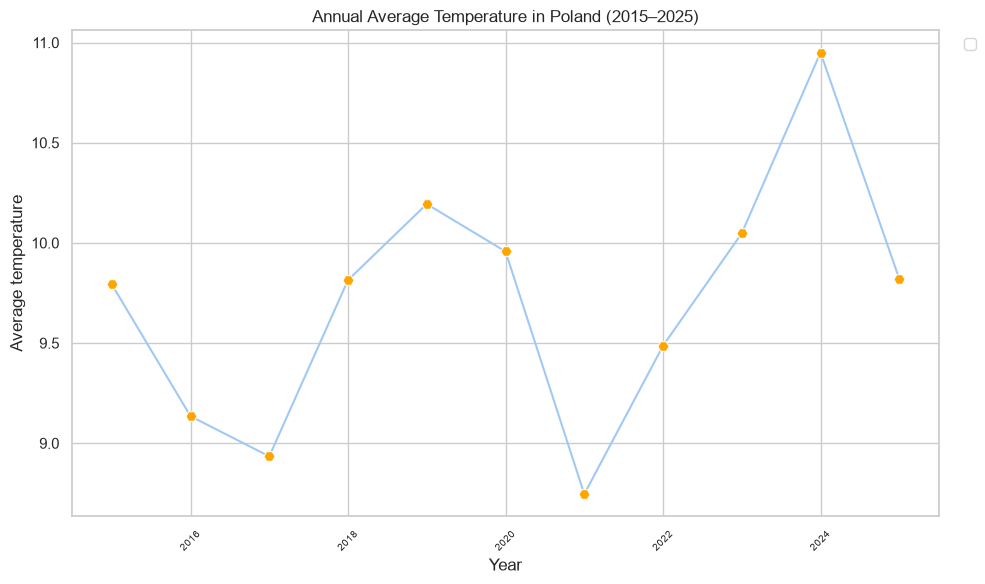

<Figure size 640x480 with 0 Axes>

In [21]:
# Add a grid in the background
sns.set_theme(
    style="whitegrid", 
    palette="pastel"
)  

# Set figure size
plt.figure(figsize=(10, 6))  

sns.lineplot(
    data=avg_temp_agg,
    marker='H',
    markersize=8,
    markerfacecolor='orange',
    x='year',
    y='avg_temp'
    )

plt.title("Annual Average Temperature in Poland (2015–2025)") # Title
plt.xlabel("Year") # x-axis name
plt.ylabel("Average temperature") # y-axis name

# Rotate x-axis labels to 45 degrees and reduce labels size
plt.xticks(rotation=45, fontsize=7)

# Position the legend outside the plot:
# X = 1.02 places it slightly to the right of the plot,
# Y = 1.00 aligns it with the top edge.
# The legend's upper-left corner is anchored at this position.
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()

# Display the plot
plt.show()

# Save the plot
plt.savefig(
    r"..\02_plots\01_average_temperature.png",
    dpi=300, # Removes unnecessary whitespace around the figure
    bbox_inches="tight" # Setting "tight" automatically crops excess whitespace so labels and titles are not cut off
)

### Annual Average Temperature by Station (2015–2025)

In [22]:
# Group by year and station_name
station_avg_temp = df.groupby(['year', 'station_name']).agg(
    avg_temp=('value', 'mean')).reset_index()

station_avg_temp.head()

,year,station_name,avg_temp
0,2015,Balice,10.015890
1,2015,Bialystok,8.707671
2,2015,Elblag-Milejewo,8.487671
3,2015,Lawica,10.635068
4,2015,Leba,9.150685


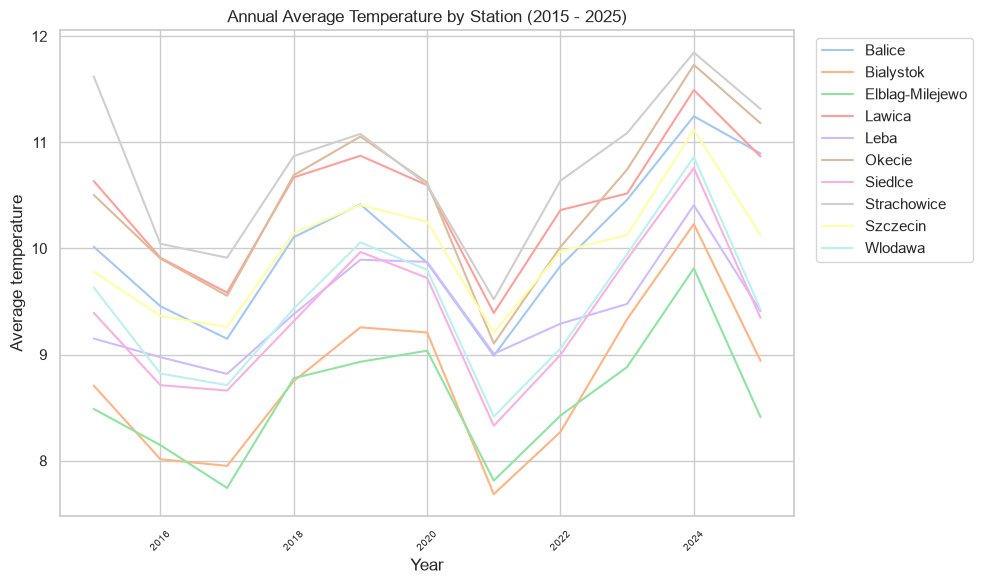

<Figure size 640x480 with 0 Axes>

In [23]:
sns.set_theme(
    style="whitegrid", 
    palette="pastel"
) 

plt.figure(figsize=(10, 6))  

sns.lineplot(
    data=station_avg_temp, 
    x='year', 
    y='avg_temp', 
    hue='station_name' # Assign a different color to each weather station
)

plt.title("Annual Average Temperature by Station (2015 - 2025)")
plt.xlabel("Year") 
plt.ylabel("Average temperature") 

plt.xticks(rotation=45, fontsize=7)

plt.legend(
    bbox_to_anchor=(1.02, 1), # 
    loc="upper left"
)
plt.tight_layout()

plt.show()

plt.savefig(
    r"..\02_plots\02_annual_average_temperature_by_station.png",
    dpi=300, 
    bbox_inches="tight" 
)

Annual temperature trends are consistent across all selected weather stations. Although absolute temperatures differ between locations, the year-to-year pattern is similar, with a pronounced decrease in 2021 and a peak in 2024.

### Correlation Between Elevation and Average Temperature (2015-2025)

In [24]:
df.head()

,station,station_name,elevation,observation_date,month_year,metric,value,year,min_obs_date,max_obs_date
3,PL000012120,Leba,2.0,2015-01-01,01-2015,TAVG,4.0,2015,2015-01-01,2025-12-31
8,PL000012385,Siedlce,152.0,2015-01-01,01-2015,TAVG,0.7,2015,2015-01-01,2025-12-31
13,PLM00012160,Elblag-Milejewo,43.0,2015-01-01,01-2015,TAVG,1.4,2015,2015-01-01,2025-12-31
16,PLM00012205,Szczecin,7.0,2015-01-01,01-2015,TAVG,3.0,2015,2015-01-01,2025-12-31
21,PLM00012295,Bialystok,151.0,2015-01-01,01-2015,TAVG,0.9,2015,2015-01-01,2025-12-31


In [25]:
# Group by year and station_name
elev = df.groupby(['station_name', 'elevation']).agg(
    avg_temp=('value', 'mean')).reset_index()

elev.head()

,station_name,elevation,avg_temp
0,Balice,241.1,10.007869
1,Bialystok,151.0,8.755514
2,Elblag-Milejewo,43.0,8.585268
3,Lawica,93.9,10.429257
4,Leba,2.0,9.423506


In [26]:
# Elevation consistency check.
# Verify that each weather station has a consistent elevation value across all 
# observations before analyzing the relationship between elevation and average temperature.
elev_qc = (
    df.groupby(['station_name', 'elevation']).agg(
    observation_count=('elevation', 'count'))
    .sort_values('observation_count', ascending=False)
    .reset_index()
    )

qc = pd.merge(
    elev_qc,
    agg_all,
    on='station_name',
    how='left'
)

qc.head()

,station_name,elevation,observation_count_x,min_date,max_date,observation_count_y
0,Szczecin,7.0,4000,2015-01-01,2025-12-31,4000
1,Bialystok,151.0,3999,2015-01-01,2025-12-31,3999
2,Siedlce,152.0,3999,2015-01-01,2025-12-31,3999
3,Leba,2.0,3999,2015-01-01,2025-12-31,3999
4,Wlodawa,179.0,3999,2015-01-01,2025-12-31,3999


In [27]:
# Compare observation counts between both DataFrames.
# .all() returns True only if every station has the same observation count.
if (qc['observation_count_x'] == qc['observation_count_y']).all():
    print("Correct.")
else:
    print("Not correct.")

Correct.


In [28]:
elev_corr_prep = df.groupby(['station_name', 'elevation']).agg(
    avg_temp=('value', 'mean')).reset_index()

elev_corr = elev_corr_prep[['elevation', 'avg_temp']]
elev_corr.corr()


,elevation,avg_temp
elevation,1.000000,0.100411
avg_temp,0.100411,1.000000


The correlation coefficient (r = 0.10) indicates a very weak positive relationship between station elevation and average temperature. Elevation alone does not appear to be a strong predictor of average temperature across the selected weather stations.

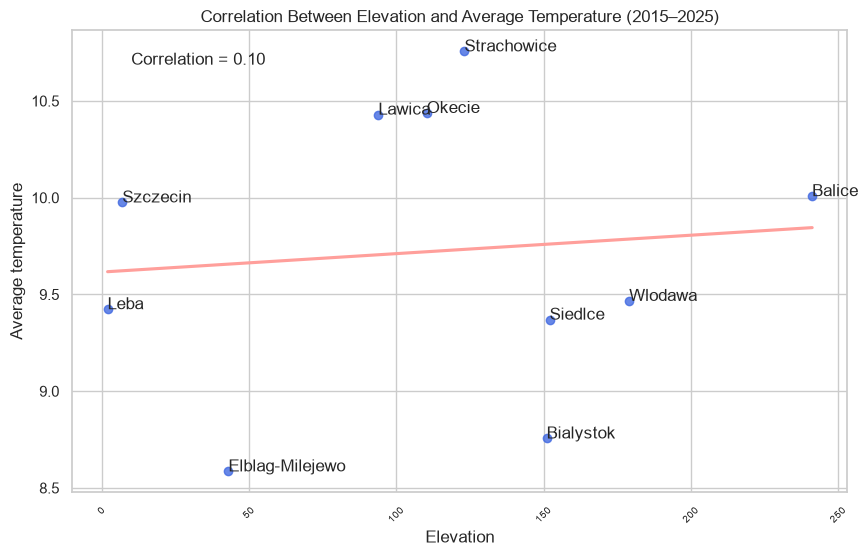

<Figure size 640x480 with 0 Axes>

In [29]:
r = 0.1

sns.set_theme(
    style="whitegrid", 
    palette="pastel"
) 

plt.figure(figsize=(10, 6))  

sns.regplot(
    x='elevation',
    y='avg_temp',
    data=elev_corr_prep,
    line_kws=dict(color="r"),
    scatter_kws={'color': 'royalblue'},
    ci=None
)

# Add station names as labels for each data point.
# Iterate through each row of the DataFrame.
for _, row in elev_corr_prep.iterrows():
    plt.text(
        x=row['elevation'],
        y=row['avg_temp'],
        s=row['station_name']
    )

plt.text(
    10,
    10.75,
    f"Correlation = {r:.2f}",
    ha='left',
    va='top'
)

plt.title("Correlation Between Elevation and Average Temperature (2015–2025)")
plt.xlabel("Elevation") 
plt.ylabel("Average temperature") 

plt.xticks(rotation=45, fontsize=7)

plt.show()

plt.savefig(
    r"..\02_plots\03_correlation_elevation_avg_temp.png",
    dpi=300, 
    bbox_inches="tight" 
)

The Pearson correlation coefficient (r = 0.10) indicates a very weak positive relationship between station elevation and average temperature. The wide dispersion of data points around the regression line suggests that elevation alone does not explain temperature differences among the analyzed weather stations. Other geographical and climatic factors are likely to have a much greater influence.

### Distribution of Daily Average Temperature by Weather Station

In [47]:
plot_raw = df.copy()
plot = plot_raw[['station_name', 'metric', 'value', 'year']]

plot

,station_name,metric,value,year
3,Leba,TAVG,4.0,2015
8,Siedlce,TAVG,0.7,2015
13,Elblag-Milejewo,TAVG,1.4,2015
16,Szczecin,TAVG,3.0,2015
21,Bialystok,TAVG,0.9,2015
...,...,...,...,...
121137,Siedlce,TAVG,-4.1,2025
121141,Elblag-Milejewo,TAVG,-4.0,2025
121145,Szczecin,TAVG,-1.1,2025
121149,Bialystok,TAVG,-9.2,2025


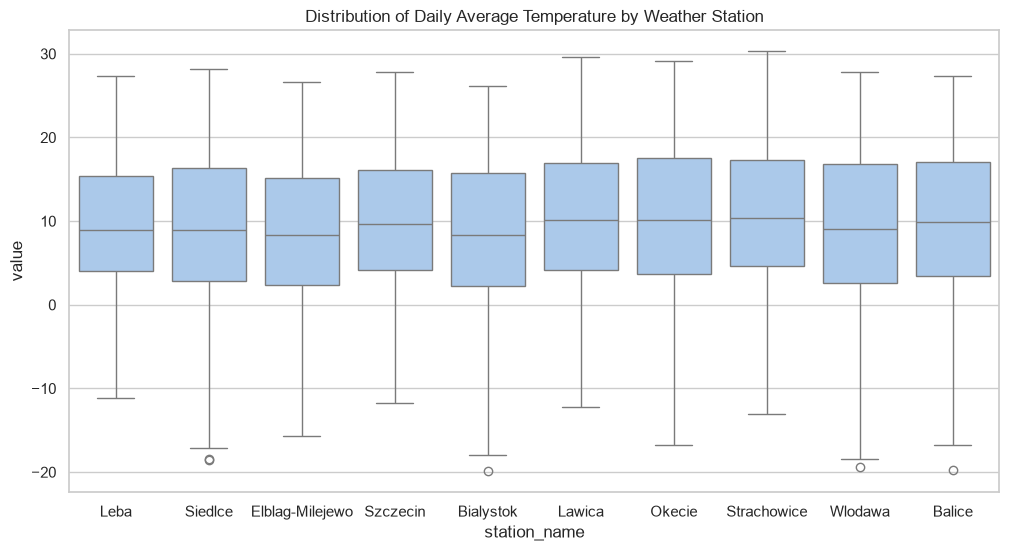

In [52]:
sns.set_theme(
    style="whitegrid", 
    palette="pastel"
) 

plt.figure(figsize=(12, 6))  

sns.boxplot(
    x='station_name',
    y='value',
    data=plot
)

plt.title("Distribution of Daily Average Temperature by Weather Station")

plt.show()

Although the selected stations differ in elevation and geographic location, their overall temperature distributions remain relatively similar. This observation is consistent with the previously calculated weak correlation between elevation and average temperature.

### Seasonal Average Temperature by Weather Station

In [58]:
df

heatmap_raw = df[['station_name', 'observation_date', 'metric', 'value']]

heatmap_raw

,station_name,observation_date,metric,value
3,Leba,2015-01-01,TAVG,4.0
8,Siedlce,2015-01-01,TAVG,0.7
13,Elblag-Milejewo,2015-01-01,TAVG,1.4
16,Szczecin,2015-01-01,TAVG,3.0
21,Bialystok,2015-01-01,TAVG,0.9
...,...,...,...,...
121137,Siedlce,2025-12-31,TAVG,-4.1
121141,Elblag-Milejewo,2025-12-31,TAVG,-4.0
121145,Szczecin,2025-12-31,TAVG,-1.1
121149,Bialystok,2025-12-31,TAVG,-9.2


In [ ]:
# Extract corresponding month number.


# Use extracted month number to assing seasons:
#   12, 1, 2 → Winter
#   3, 4, 5 → Spring
#   6, 7, 8 → Summer
#   9, 10, 11 → Autumn


# Calculate average temperature for each season (use groupby, two columns)